In [1]:
# Install required packages
!pip install -q torch torchvision
!pip install -q opencv-python-headless
!pip install -q albumentations
!pip install -q shap
!pip install -q grad-cam
!pip install -q matplotlib scikit-learn tqdm

print('✅ All packages installed.')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 78.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
✅ All packages installed.


In [2]:
import os, cv2, shap, warnings, random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms.functional as TF

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.metrics import f1_score
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import SemanticSegmentationTarget

warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'✅ Using device: {DEVICE}')

✅ Using device: cuda


In [8]:
from google.colab import drive
drive.mount('/content/drive')

# ─── UPDATE THESE PATHS to match your Drive folder structure ───
BASE_DIR  = '/content/drive/MyDrive/major_project_full'
IMG_DIR   = f'{BASE_DIR}/images'
MASK_DIR  = f'{BASE_DIR}/mask_images'
OUTPUT_DIR = f'{BASE_DIR}/output'
# ───────────────────────────────────────────────────────────────

os.makedirs(OUTPUT_DIR, exist_ok=True)

images = sorted(os.listdir(IMG_DIR))
masks  = sorted(os.listdir(MASK_DIR))

print(f'📦 Dataset     : Common Carotid Artery (CCA) — Mendeley')
print(f'🖼️  Total Images: {len(images)}')
print(f'🎭  Total Masks : {len(masks)}')

assert len(images) == len(masks), '❌ Mismatch between images and masks!'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📦 Dataset     : Common Carotid Artery (CCA) — Mendeley
🖼️  Total Images: 1100
🎭  Total Masks : 1100


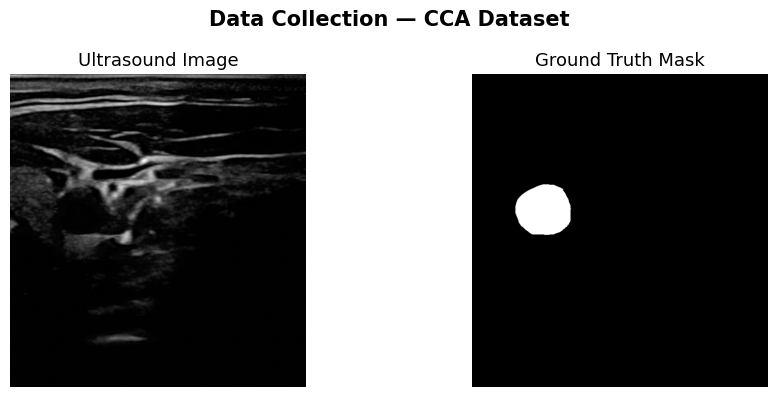

Image shape: (749, 709) | Mask shape: (749, 709)


In [10]:
# Quick sanity check — display a sample image + mask
sample = images[0]
img  = cv2.imread(f'{IMG_DIR}/{sample}',  cv2.IMREAD_GRAYSCALE)
mask = cv2.imread(f'{MASK_DIR}/{sample}', cv2.IMREAD_GRAYSCALE)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img,  cmap='gray'); axes[0].set_title('Ultrasound Image', fontsize=13); axes[0].axis('off')
axes[1].imshow(mask, cmap='gray'); axes[1].set_title('Ground Truth Mask', fontsize=13); axes[1].axis('off')
plt.suptitle('Data Collection — CCA Dataset', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/slide1_collection.png', dpi=150)
plt.show()
print(f'Image shape: {img.shape} | Mask shape: {mask.shape}')

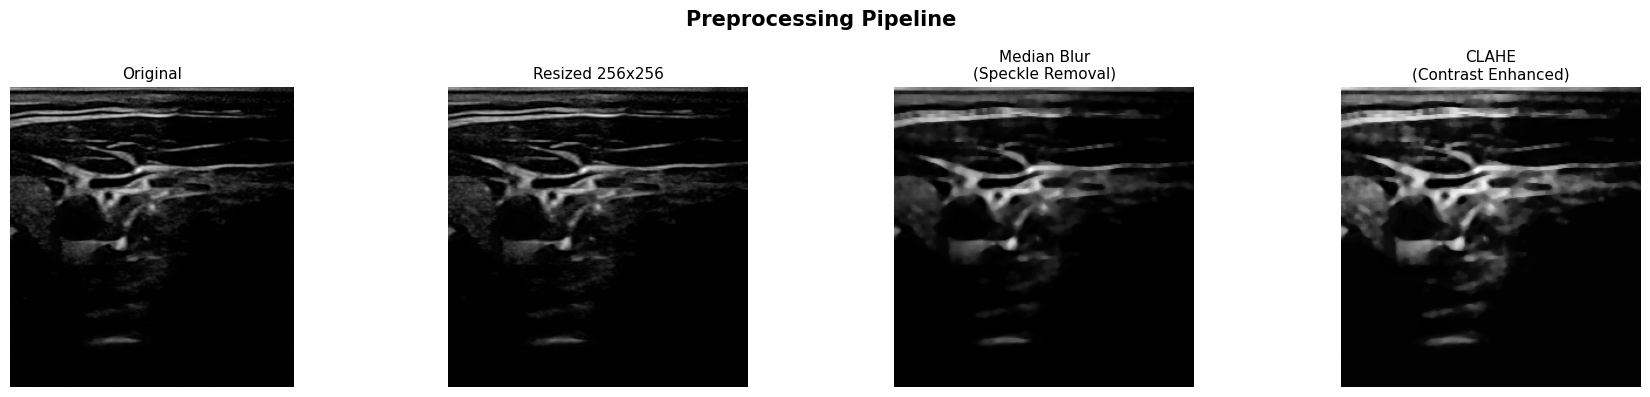

✅ Preprocessing pipeline validated.


In [11]:
IMG_SIZE = 256  # Resize all images to 256x256

def preprocess_image(img_path, img_size=IMG_SIZE):
    """
    Full preprocessing pipeline:
      1. Load grayscale
      2. Resize to img_size x img_size
      3. Median blur (speckle noise removal)
      4. CLAHE (contrast enhancement)
      5. Normalize to [0, 1]
    Returns: numpy array (H, W) float32
    """
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (img_size, img_size))
    img = cv2.medianBlur(img, 5)                              # Speckle filter
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img = clahe.apply(img)                                    # Contrast enhance
    img = img.astype(np.float32) / 255.0                     # Normalize
    return img

def preprocess_mask(mask_path, img_size=IMG_SIZE):
    """
    Mask preprocessing:
      1. Load grayscale
      2. Resize (nearest neighbour to preserve binary labels)
      3. Binarize at threshold 0.5
    Returns: numpy array (H, W) float32 with values {0, 1}
    """
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, (img_size, img_size), interpolation=cv2.INTER_NEAREST)
    mask = (mask > 127).astype(np.float32)                   # Binarize
    return mask

# Visualize preprocessing stages
raw  = cv2.imread(f'{IMG_DIR}/{images[0]}', cv2.IMREAD_GRAYSCALE)
rsz  = cv2.resize(raw, (IMG_SIZE, IMG_SIZE))
dnz  = cv2.medianBlur(rsz, 5)
clahe_obj = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
enh  = clahe_obj.apply(dnz)
nrm  = enh.astype(np.float32) / 255.0

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, img_data, title in zip(axes,
    [raw, rsz, dnz, enh],
    ['Original', f'Resized {IMG_SIZE}x{IMG_SIZE}', 'Median Blur\n(Speckle Removal)', 'CLAHE\n(Contrast Enhanced)']):
    ax.imshow(img_data, cmap='gray'); ax.set_title(title, fontsize=11); ax.axis('off')
plt.suptitle('Preprocessing Pipeline', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/slide2_preprocessing.png', dpi=150)
plt.show()
print('✅ Preprocessing pipeline validated.')

In [12]:
# Augmentation transforms (training only)
TRAIN_TRANSFORM = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.Rotate(limit=15, p=0.4),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.4),
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),
    A.ElasticTransform(alpha=1, sigma=50, p=0.2),   # Mimics anatomical variation
    ToTensorV2()
])

VAL_TRANSFORM = A.Compose([ToTensorV2()])


class CarotidDataset(Dataset):
    """
    PyTorch Dataset for Carotid Artery Ultrasound.
    Returns preprocessed (image, mask) pairs as tensors.
    """
    def __init__(self, img_dir, mask_dir, img_size=IMG_SIZE, transform=None):
        self.img_dir   = img_dir
        self.mask_dir  = mask_dir
        self.img_size  = img_size
        self.transform = transform
        self.filenames = sorted([
            f for f in os.listdir(img_dir)
            if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))
        ])

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        fname = self.filenames[idx]
        img  = preprocess_image(f'{self.img_dir}/{fname}',  self.img_size)  # (H,W) float32
        mask = preprocess_mask(f'{self.mask_dir}/{fname}', self.img_size)  # (H,W) float32

        if self.transform:
            aug = self.transform(image=img, mask=mask)
            img, mask = aug['image'], aug['mask']
        else:
            img  = torch.from_numpy(img).unsqueeze(0)   # (1,H,W)
            mask = torch.from_numpy(mask).unsqueeze(0)  # (1,H,W)

        # Albumentations ToTensorV2 on single-channel needs unsqueeze
        if img.dim() == 2:   img  = img.unsqueeze(0)
        if mask.dim() == 2:  mask = mask.unsqueeze(0)

        return img.float(), mask.float()


# Build full dataset, then split 70/15/15
full_dataset = CarotidDataset(IMG_DIR, MASK_DIR)
total = len(full_dataset)
n_train = int(0.70 * total)
n_val   = int(0.15 * total)
n_test  = total - n_train - n_val

train_ds, val_ds, test_ds = random_split(
    full_dataset, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(SEED)
)

# Apply transforms
train_ds.dataset.transform = TRAIN_TRANSFORM
val_ds.dataset.transform   = VAL_TRANSFORM
test_ds.dataset.transform  = VAL_TRANSFORM

BATCH_SIZE = 8
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'✅ Dataset split — Train: {n_train} | Val: {n_val} | Test: {n_test}')
print(f'   Batch size: {BATCH_SIZE} | Train batches: {len(train_loader)}')

✅ Dataset split — Train: 770 | Val: 165 | Test: 165
   Batch size: 8 | Train batches: 97


In [13]:
class DoubleConv(nn.Module):
    """Two consecutive Conv → BN → ReLU blocks (the core U-Net building block)."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    """
    U-Net for binary segmentation.
    Encoder: 4 downsampling stages with MaxPool2d.
    Bottleneck: DoubleConv at 1024 channels.
    Decoder: 4 upsampling stages with skip connections.
    Output: sigmoid-activated single-channel mask.
    """
    def __init__(self, in_channels=1, out_channels=1, features=[64, 128, 256, 512]):
        super().__init__()
        self.encoder = nn.ModuleList()
        self.decoder = nn.ModuleList()
        self.pool    = nn.MaxPool2d(kernel_size=2, stride=2)

        # ─── Encoder ───
        ch = in_channels
        for f in features:
            self.encoder.append(DoubleConv(ch, f))
            ch = f

        # ─── Bottleneck ───
        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

        # ─── Decoder ───
        for f in reversed(features):
            self.decoder.append(nn.ConvTranspose2d(f * 2, f, kernel_size=2, stride=2))
            self.decoder.append(DoubleConv(f * 2, f))

        # ─── Output head ───
        self.output_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []

        # Encode
        for enc in self.encoder:
            x = enc(x)
            skip_connections.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]  # Reverse for decoder

        # Decode
        for i in range(0, len(self.decoder), 2):
            x    = self.decoder[i](x)               # Upsample
            skip = skip_connections[i // 2]
            if x.shape != skip.shape:               # Handle odd dimensions
                x = F.interpolate(x, size=skip.shape[2:])
            x = torch.cat([skip, x], dim=1)         # Skip connection
            x = self.decoder[i + 1](x)              # DoubleConv

        return torch.sigmoid(self.output_conv(x))


model = UNet(in_channels=1, out_channels=1).to(DEVICE)

# Parameter count
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'✅ U-Net built — {total_params:,} trainable parameters')

# Quick shape check
dummy = torch.zeros(1, 1, IMG_SIZE, IMG_SIZE).to(DEVICE)
out   = model(dummy)
print(f'   Input shape: {dummy.shape} → Output shape: {out.shape}')

✅ U-Net built — 31,036,481 trainable parameters
   Input shape: torch.Size([1, 1, 256, 256]) → Output shape: torch.Size([1, 1, 256, 256])


In [14]:
def dice_loss(pred, target, smooth=1e-6):
    """
    Dice Loss = 1 - (2 * |pred ∩ target|) / (|pred| + |target|)
    Penalizes overlap mismatch — critical for medical segmentation
    where foreground (artery) pixels are rare.
    """
    pred   = pred.view(-1)
    target = target.view(-1)
    inter  = (pred * target).sum()
    return 1 - (2 * inter + smooth) / (pred.sum() + target.sum() + smooth)


def combined_loss(pred, target, bce_weight=0.5):
    """
    Combined BCE + Dice Loss.
    BCE handles pixel-wise accuracy; Dice handles region overlap.
    """
    bce  = F.binary_cross_entropy(pred, target)
    dice = dice_loss(pred, target)
    return bce_weight * bce + (1 - bce_weight) * dice


@torch.no_grad()
def compute_metrics(pred, target, threshold=0.5):
    """
    Compute Dice Score, IoU (Jaccard), and Pixel Accuracy.
    Args:
        pred   : (B, 1, H, W) float sigmoid output
        target : (B, 1, H, W) float binary mask
    """
    pred_bin = (pred > threshold).float()
    smooth   = 1e-6

    p = pred_bin.view(-1)
    t = target.view(-1)

    inter   = (p * t).sum()
    union   = p.sum() + t.sum() - inter

    dice    = (2 * inter + smooth) / (p.sum() + t.sum() + smooth)
    iou     = (inter + smooth) / (union + smooth)
    acc     = (p == t).float().mean()

    return dice.item(), iou.item(), acc.item()


print('✅ Loss functions and metrics defined.')

✅ Loss functions and metrics defined.


In [17]:
EPOCHS    = 50
LR        = 1e-4
PATIENCE  = 10   # Early stopping patience

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

# ─── Training State ───
history = {'train_loss': [], 'val_loss': [], 'val_dice': [], 'val_iou': []}
best_val_loss   = float('inf')
best_model_path = f'{OUTPUT_DIR}/best_unet.pt'
patience_count  = 0

print(f'🚀 Starting training | Epochs: {EPOCHS} | LR: {LR} | Device: {DEVICE}\n')

for epoch in range(1, EPOCHS + 1):

    # ─── Train ───
    model.train()
    train_loss = 0.0
    for imgs, masks in tqdm(train_loader, desc=f'Epoch {epoch:02d}/{EPOCHS} [Train]', leave=False):
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        optimizer.zero_grad()
        preds = model(imgs)
        loss  = combined_loss(preds, masks)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # ─── Validate ───
    model.eval()
    val_loss, val_dice, val_iou = 0.0, 0.0, 0.0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            preds = model(imgs)
            val_loss += combined_loss(preds, masks).item()
            d, iou, _ = compute_metrics(preds, masks)
            val_dice += d; val_iou += iou
    val_loss /= len(val_loader)
    val_dice /= len(val_loader)
    val_iou  /= len(val_loader)

    # ─── Log ───
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_dice'].append(val_dice)
    history['val_iou'].append(val_iou)

    scheduler.step(val_loss)

    print(f'Epoch {epoch:02d}/{EPOCHS} | '
          f'Train Loss: {train_loss:.4f} | '
          f'Val Loss: {val_loss:.4f} | '
          f'Dice: {val_dice:.4f} | IoU: {val_iou:.4f}')

    # ─── Early stopping + checkpoint ───
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_model_path)
        patience_count = 0
        print(f'   💾 Best model saved (val_loss={val_loss:.4f})')
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f'   ⏹️  Early stopping at epoch {epoch} (no improvement for {PATIENCE} epochs)')
            break

print('\n✅ Training complete.')

🚀 Starting training | Epochs: 50 | LR: 0.0001 | Device: cuda



Epoch 01/50 | Train Loss: 0.6335 | Val Loss: 0.5752 | Dice: 0.8912 | IoU: 0.8044
   💾 Best model saved (val_loss=0.5752)


Epoch 02/50 | Train Loss: 0.5531 | Val Loss: 0.5367 | Dice: 0.9163 | IoU: 0.8456
   💾 Best model saved (val_loss=0.5367)


Epoch 03/50 | Train Loss: 0.5209 | Val Loss: 0.5169 | Dice: 0.8697 | IoU: 0.7716
   💾 Best model saved (val_loss=0.5169)


Epoch 04/50 | Train Loss: 0.4909 | Val Loss: 0.4849 | Dice: 0.9233 | IoU: 0.8578
   💾 Best model saved (val_loss=0.4849)


...

Epoch 46/50 | Train Loss: 0.0192 | Val Loss: 0.0347 | Dice: 0.9525 | IoU: 0.9096


Epoch 47/50 | Train Loss: 0.0212 | Val Loss: 0.0301 | Dice: 0.9591 | IoU: 0.9217
   💾 Best model saved (val_loss=0.0301)


Epoch 48/50 | Train Loss: 0.0186 | Val Loss: 0.0302 | Dice: 0.9590 | IoU: 0.9215


Epoch 49/50 | Train Loss: 0.0188 | Val Loss: 0.0307 | Dice: 0.9574 | IoU: 0.9185


Epoch 50/50 | Train Loss: 0.0277 | Val Loss: 0.0346 | Dice: 0.9524 | IoU: 0.9095

✅ Training complete.


In [18]:
import json

# Save training history to Drive
history_path = f'{OUTPUT_DIR}/training_history.json'
with open(history_path, 'w') as f:
    json.dump(history, f)

print(f'✅ Training history saved to {history_path}')
print(f'✅ Best model already saved to {OUTPUT_DIR}/best_unet.pt')

✅ Training history saved to /content/drive/MyDrive/major_project_full/output/training_history.json
✅ Best model already saved to /content/drive/MyDrive/major_project_full/output/best_unet.pt


In [19]:
import json

# Load model
model.load_state_dict(torch.load(f'{OUTPUT_DIR}/best_unet.pt', map_location=DEVICE))
model.eval()

# Load history (for plotting curves)
with open(f'{OUTPUT_DIR}/training_history.json', 'r') as f:
    history = json.load(f)

print('✅ Model loaded — Skipping training')
print(f'   Best Dice seen : {max(history["val_dice"]):.4f}')
print(f'   Best IoU seen  : {max(history["val_iou"]):.4f}')
print(f'   Best Val Loss  : {min(history["val_loss"]):.4f}')


✅ Model loaded — Skipping training
   Best Dice seen : 0.9600
   Best IoU seen  : 0.9232
   Best Val Loss  : 0.0301


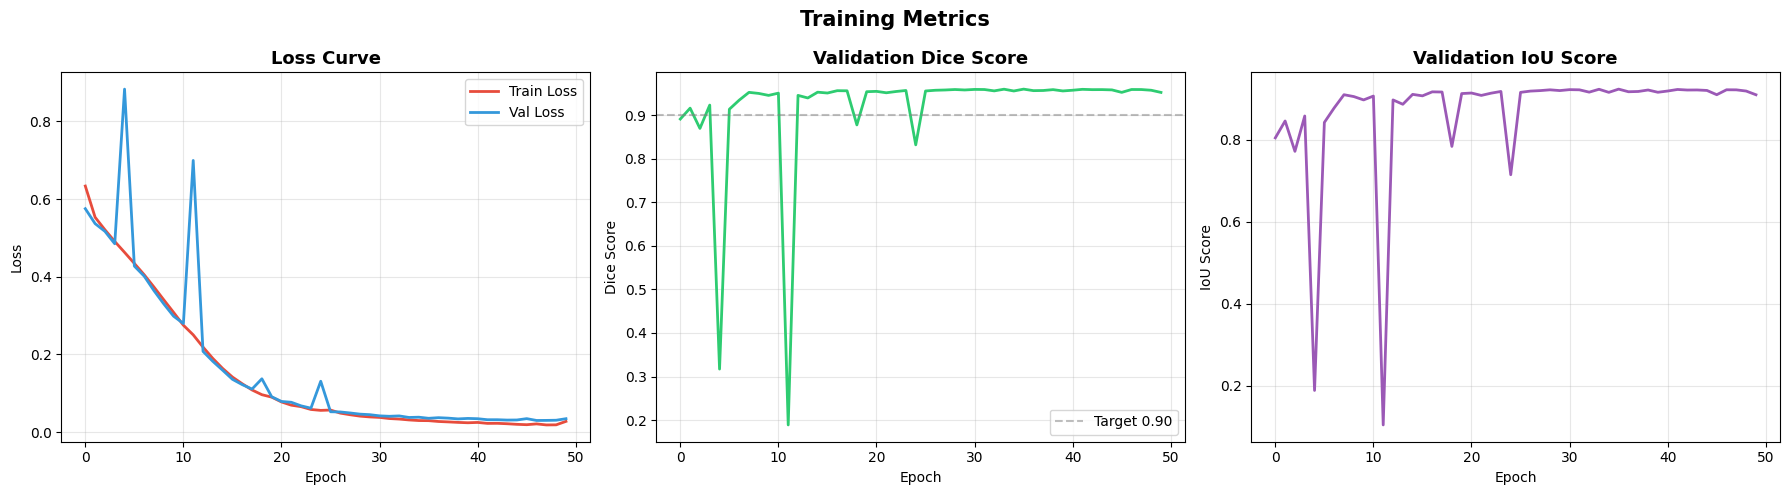

In [20]:
# Plot training curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history['train_loss'], label='Train Loss', color='#E74C3C', linewidth=2)
axes[0].plot(history['val_loss'],   label='Val Loss',   color='#3498DB', linewidth=2)
axes[0].set_title('Loss Curve', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history['val_dice'], color='#2ECC71', linewidth=2)
axes[1].set_title('Validation Dice Score', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Dice Score'); axes[1].grid(alpha=0.3)
axes[1].axhline(y=0.9, color='gray', linestyle='--', alpha=0.5, label='Target 0.90')
axes[1].legend()

axes[2].plot(history['val_iou'], color='#9B59B6', linewidth=2)
axes[2].set_title('Validation IoU Score', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('IoU Score'); axes[2].grid(alpha=0.3)

plt.suptitle('Training Metrics', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/training_curves.png', dpi=150)
plt.show()

Evaluating on test set: 100%|██████████| 21/21 [01:33<00:00,  4.47s/it]


📊  TEST SET RESULTS
   Dice Score      : 0.9618
   IoU (Jaccard)   : 0.9266
   F1 Score        : 0.9619
   Pixel Accuracy  : 0.9982


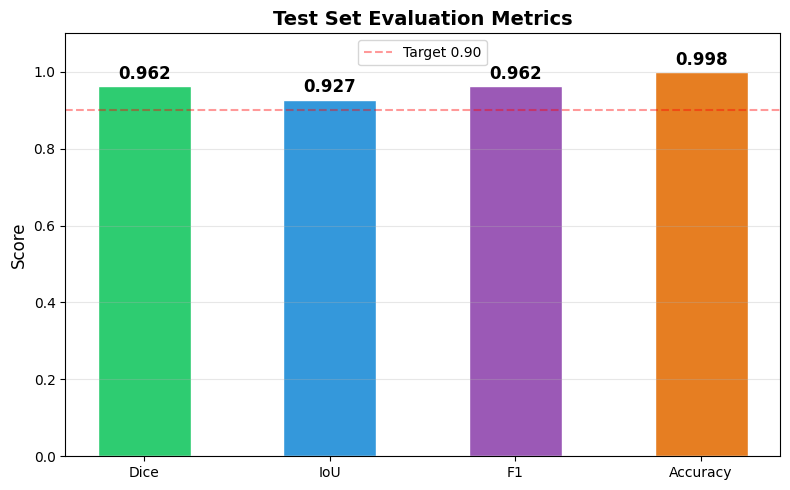

In [21]:
# Load best model weights
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
model.eval()

all_preds, all_targets = [], []
test_dice, test_iou, test_acc = 0.0, 0.0, 0.0

with torch.no_grad():
    for imgs, masks in tqdm(test_loader, desc='Evaluating on test set'):
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        preds = model(imgs)
        d, iou, acc = compute_metrics(preds, masks)
        test_dice += d; test_iou += iou; test_acc += acc
        all_preds.append((preds > 0.5).cpu().numpy())
        all_targets.append(masks.cpu().numpy())

n = len(test_loader)
test_dice /= n; test_iou /= n; test_acc /= n

# Compute F1 on flattened arrays
p_flat = np.concatenate([x.flatten() for x in all_preds])
t_flat = np.concatenate([x.flatten() for x in all_targets])
test_f1 = f1_score(t_flat, p_flat)

print('=' * 50)
print('📊  TEST SET RESULTS')
print('=' * 50)
print(f'   Dice Score      : {test_dice:.4f}')
print(f'   IoU (Jaccard)   : {test_iou:.4f}')
print(f'   F1 Score        : {test_f1:.4f}')
print(f'   Pixel Accuracy  : {test_acc:.4f}')
print('=' * 50)

# Bar chart of metrics
metrics = {'Dice': test_dice, 'IoU': test_iou, 'F1': test_f1, 'Accuracy': test_acc}
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#2ECC71', '#3498DB', '#9B59B6', '#E67E22']
bars = ax.bar(metrics.keys(), metrics.values(), color=colors, width=0.5, edgecolor='white')
for bar, val in zip(bars, metrics.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_ylim(0, 1.1); ax.set_ylabel('Score', fontsize=12)
ax.set_title('Test Set Evaluation Metrics', fontsize=14, fontweight='bold')
ax.axhline(0.9, color='red', linestyle='--', alpha=0.4, label='Target 0.90')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/test_metrics.png', dpi=150)
plt.show()

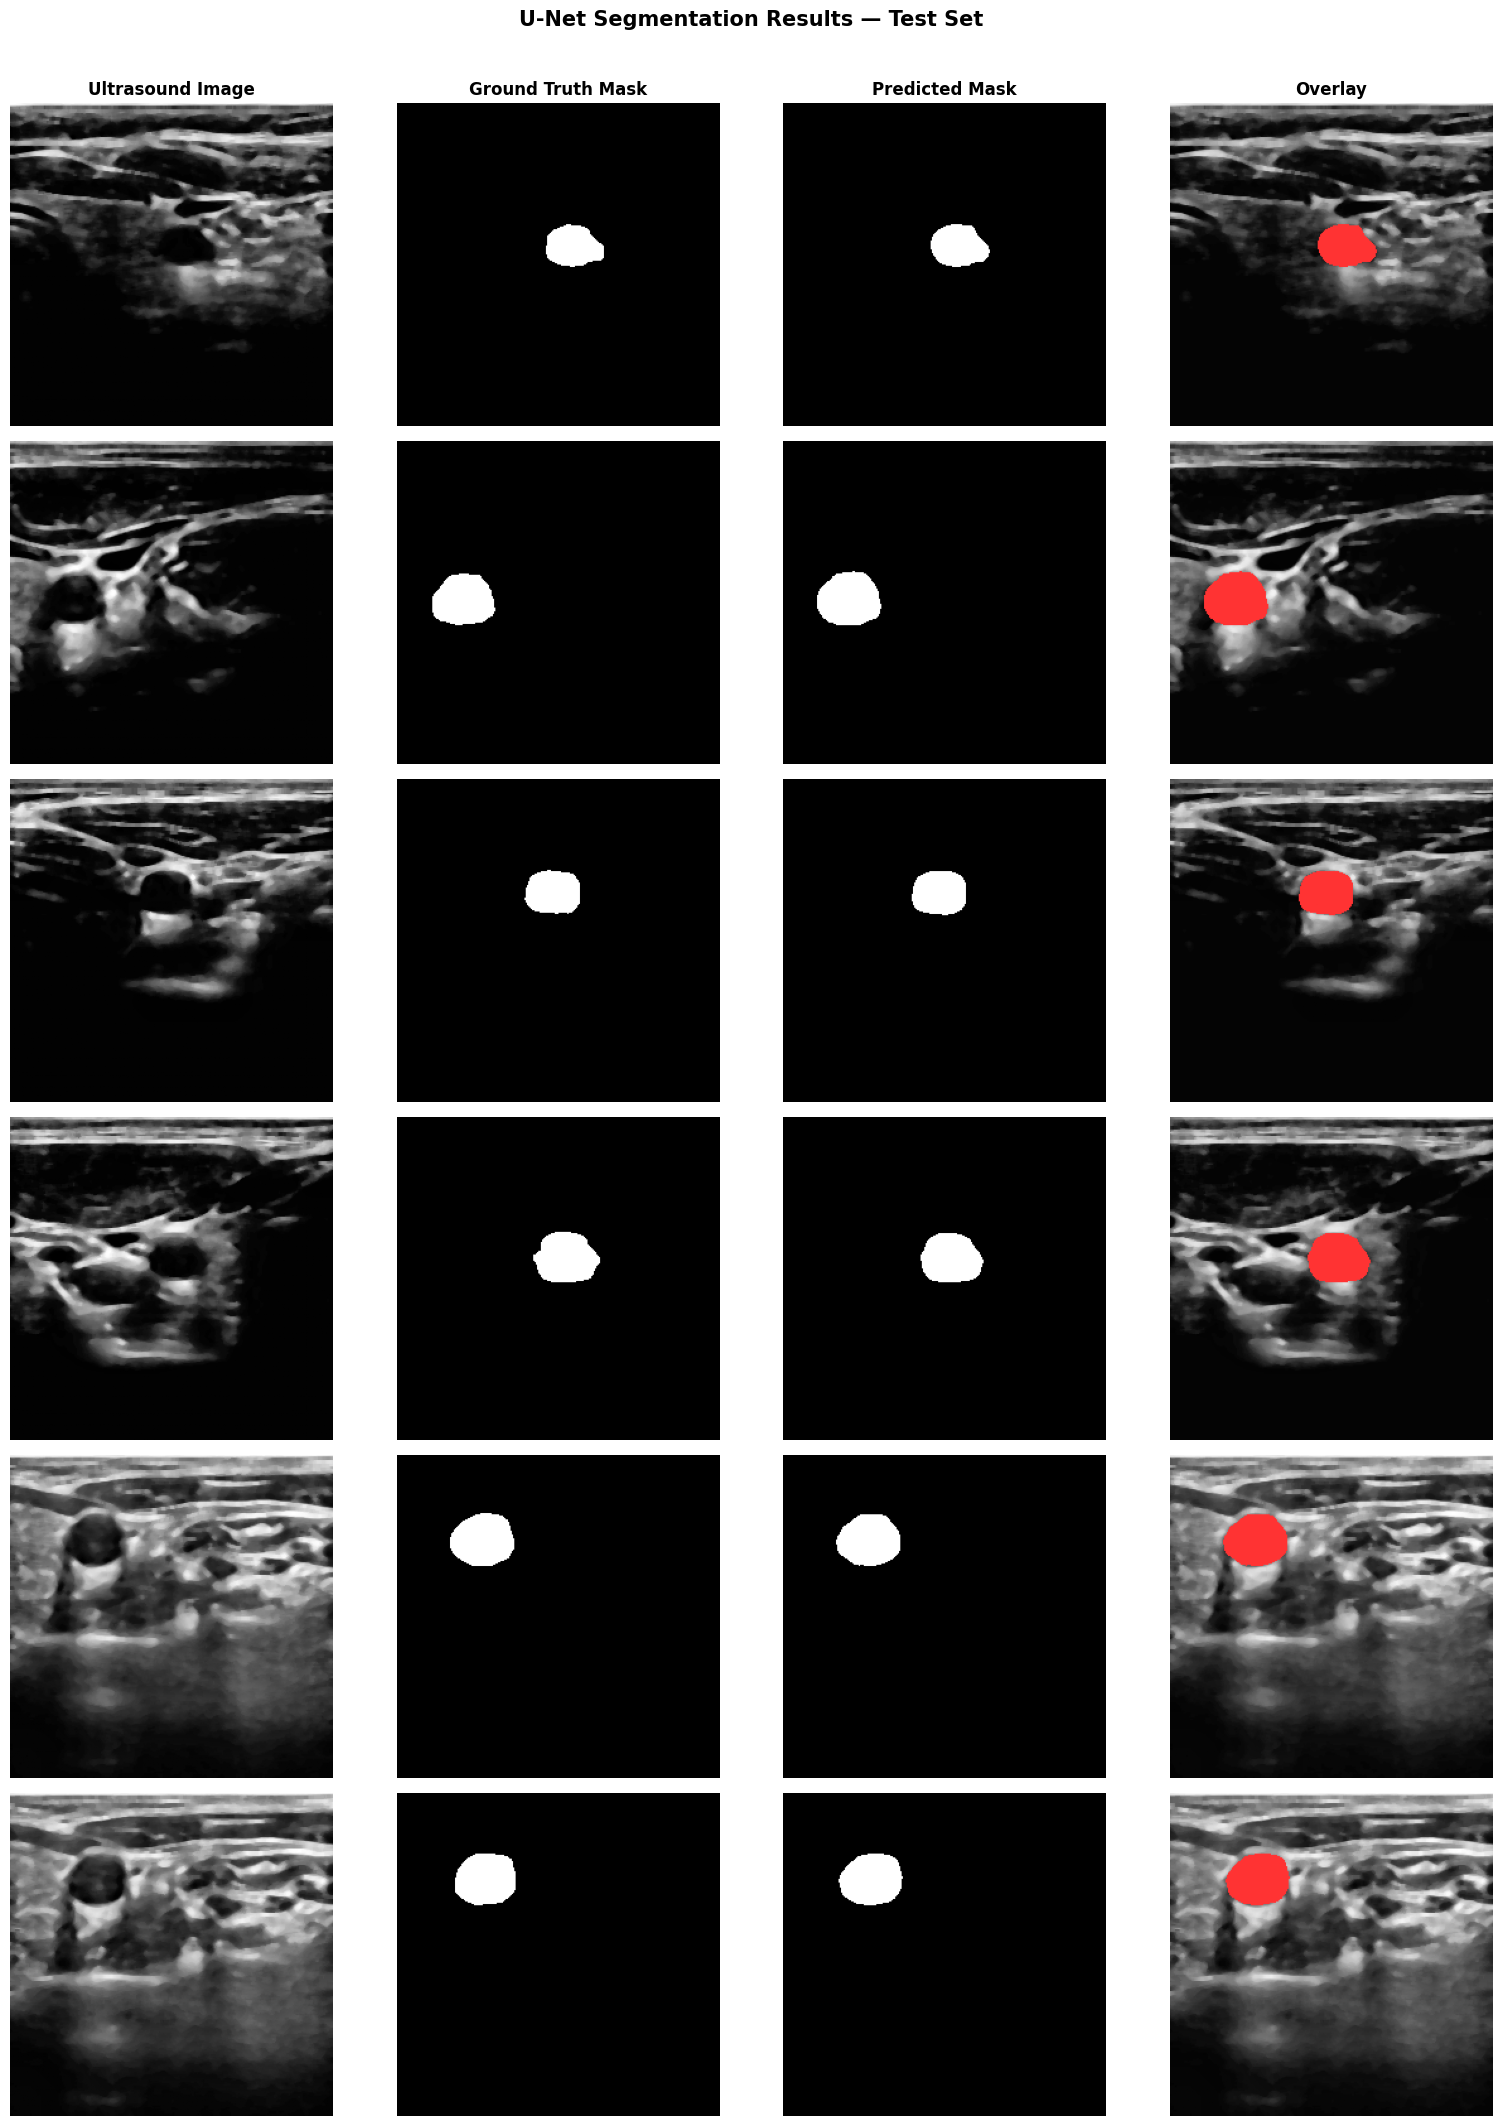

In [22]:
def visualize_predictions(model, dataset, n_samples=6, device=DEVICE):
    """
    Display n_samples of: Input Image | Ground Truth | Prediction | Overlay
    """
    model.eval()
    indices = random.sample(range(len(dataset)), n_samples)

    fig, axes = plt.subplots(n_samples, 4, figsize=(16, n_samples * 3.5))
    col_titles = ['Ultrasound Image', 'Ground Truth Mask', 'Predicted Mask', 'Overlay']
    for ax, title in zip(axes[0], col_titles):
        ax.set_title(title, fontsize=12, fontweight='bold')

    for row, idx in enumerate(indices):
        img, mask = dataset[idx]
        with torch.no_grad():
            pred = model(img.unsqueeze(0).to(device)).squeeze().cpu().numpy()

        img_np  = img.squeeze().numpy()
        mask_np = mask.squeeze().numpy()
        pred_bin = (pred > 0.5).astype(np.float32)

        # Overlay: image + colored prediction
        img_rgb = np.stack([img_np]*3, axis=-1)
        overlay = img_rgb.copy()
        overlay[pred_bin == 1, 0] = 1.0   # Red channel highlights prediction
        overlay[pred_bin == 1, 1] = 0.2
        overlay[pred_bin == 1, 2] = 0.2

        d, iou, _ = compute_metrics(
            torch.tensor(pred).unsqueeze(0).unsqueeze(0),
            torch.tensor(mask_np).unsqueeze(0).unsqueeze(0)
        )

        axes[row, 0].imshow(img_np,   cmap='gray');  axes[row, 0].axis('off')
        axes[row, 1].imshow(mask_np,  cmap='gray');  axes[row, 1].axis('off')
        axes[row, 2].imshow(pred_bin, cmap='gray');  axes[row, 2].axis('off')
        axes[row, 3].imshow(overlay);                axes[row, 3].axis('off')
        axes[row, 0].set_ylabel(f'Dice={d:.3f}\nIoU={iou:.3f}', fontsize=10, rotation=0,
                                 labelpad=60, va='center')

    plt.suptitle('U-Net Segmentation Results — Test Set', fontsize=15, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/predictions.png', dpi=150, bbox_inches='tight')
    plt.show()


visualize_predictions(model, test_ds)

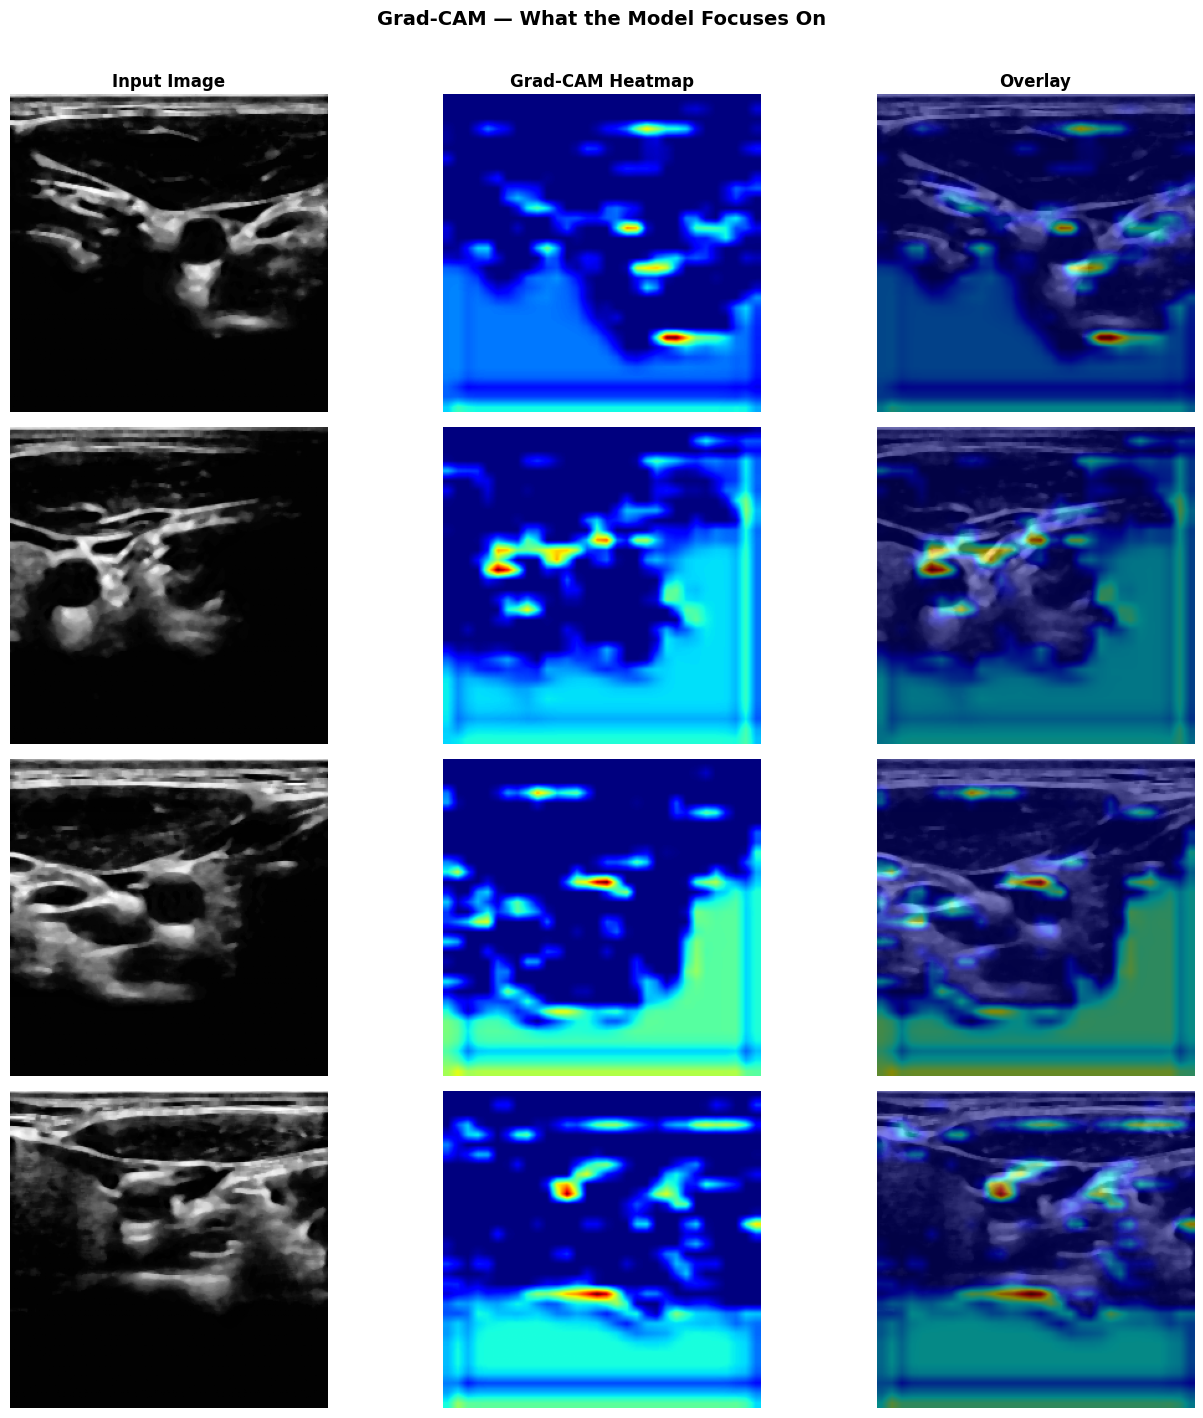

✅ Grad-CAM visualization saved.


In [23]:
class SegmentationModelWrapper(nn.Module):
    """
    Wrapper so GradCAM can treat the U-Net as a classifier.
    Reduces spatial output to a scalar via mean pooling.
    """
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        seg = self.model(x)          # (B, 1, H, W)
        return seg.mean(dim=[2, 3])  # (B, 1) — scalar per sample


def apply_gradcam(model, dataset, n_samples=4, device=DEVICE):
    """
    Apply Grad-CAM to U-Net encoder's last layer.
    Shows heatmap of attention over the ultrasound image.
    """
    model.eval()
    target_layer = model.encoder[-1].block[-2]   # Last BN in encoder

    with GradCAM(model=model, target_layers=[target_layer]) as cam:
        fig, axes = plt.subplots(n_samples, 3, figsize=(14, n_samples * 3.5))
        for ax, title in zip(axes[0], ['Input Image', 'Grad-CAM Heatmap', 'Overlay']):
            ax.set_title(title, fontsize=12, fontweight='bold')

        indices = random.sample(range(len(dataset)), n_samples)

        for row, idx in enumerate(indices):
            img, mask = dataset[idx]
            input_tensor = img.unsqueeze(0).to(device)

            # Grad-CAM targets: maximize foreground activation
            targets = [SemanticSegmentationTarget(0, mask.squeeze().numpy())]
            grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]  # (H, W)

            img_np  = img.squeeze().numpy()
            img_rgb = np.stack([img_np]*3, axis=-1).astype(np.float32)

            cam_overlay = show_cam_on_image(img_rgb, grayscale_cam, use_rgb=True)

            axes[row, 0].imshow(img_np, cmap='gray');    axes[row, 0].axis('off')
            axes[row, 1].imshow(grayscale_cam, cmap='jet'); axes[row, 1].axis('off')
            axes[row, 2].imshow(cam_overlay);            axes[row, 2].axis('off')

    plt.suptitle('Grad-CAM — What the Model Focuses On', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/gradcam.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Grad-CAM visualization saved.')


apply_gradcam(model, test_ds)

In [29]:
# Step 1: Clear GPU memory
torch.cuda.empty_cache()
import gc; gc.collect()
print('✅ GPU memory cleared')

✅ GPU memory cleared


In [34]:
model.load_state_dict(
    torch.load(f'{OUTPUT_DIR}/best_unet.pt', map_location=DEVICE),
    strict=False
)
model.eval()
print('✅ Model loaded')

✅ Model loaded


⏳ Sample 1/4...
✅ Sample 1/4 done
⏳ Sample 2/4...
✅ Sample 2/4 done
⏳ Sample 3/4...
✅ Sample 3/4 done
⏳ Sample 4/4...
✅ Sample 4/4 done


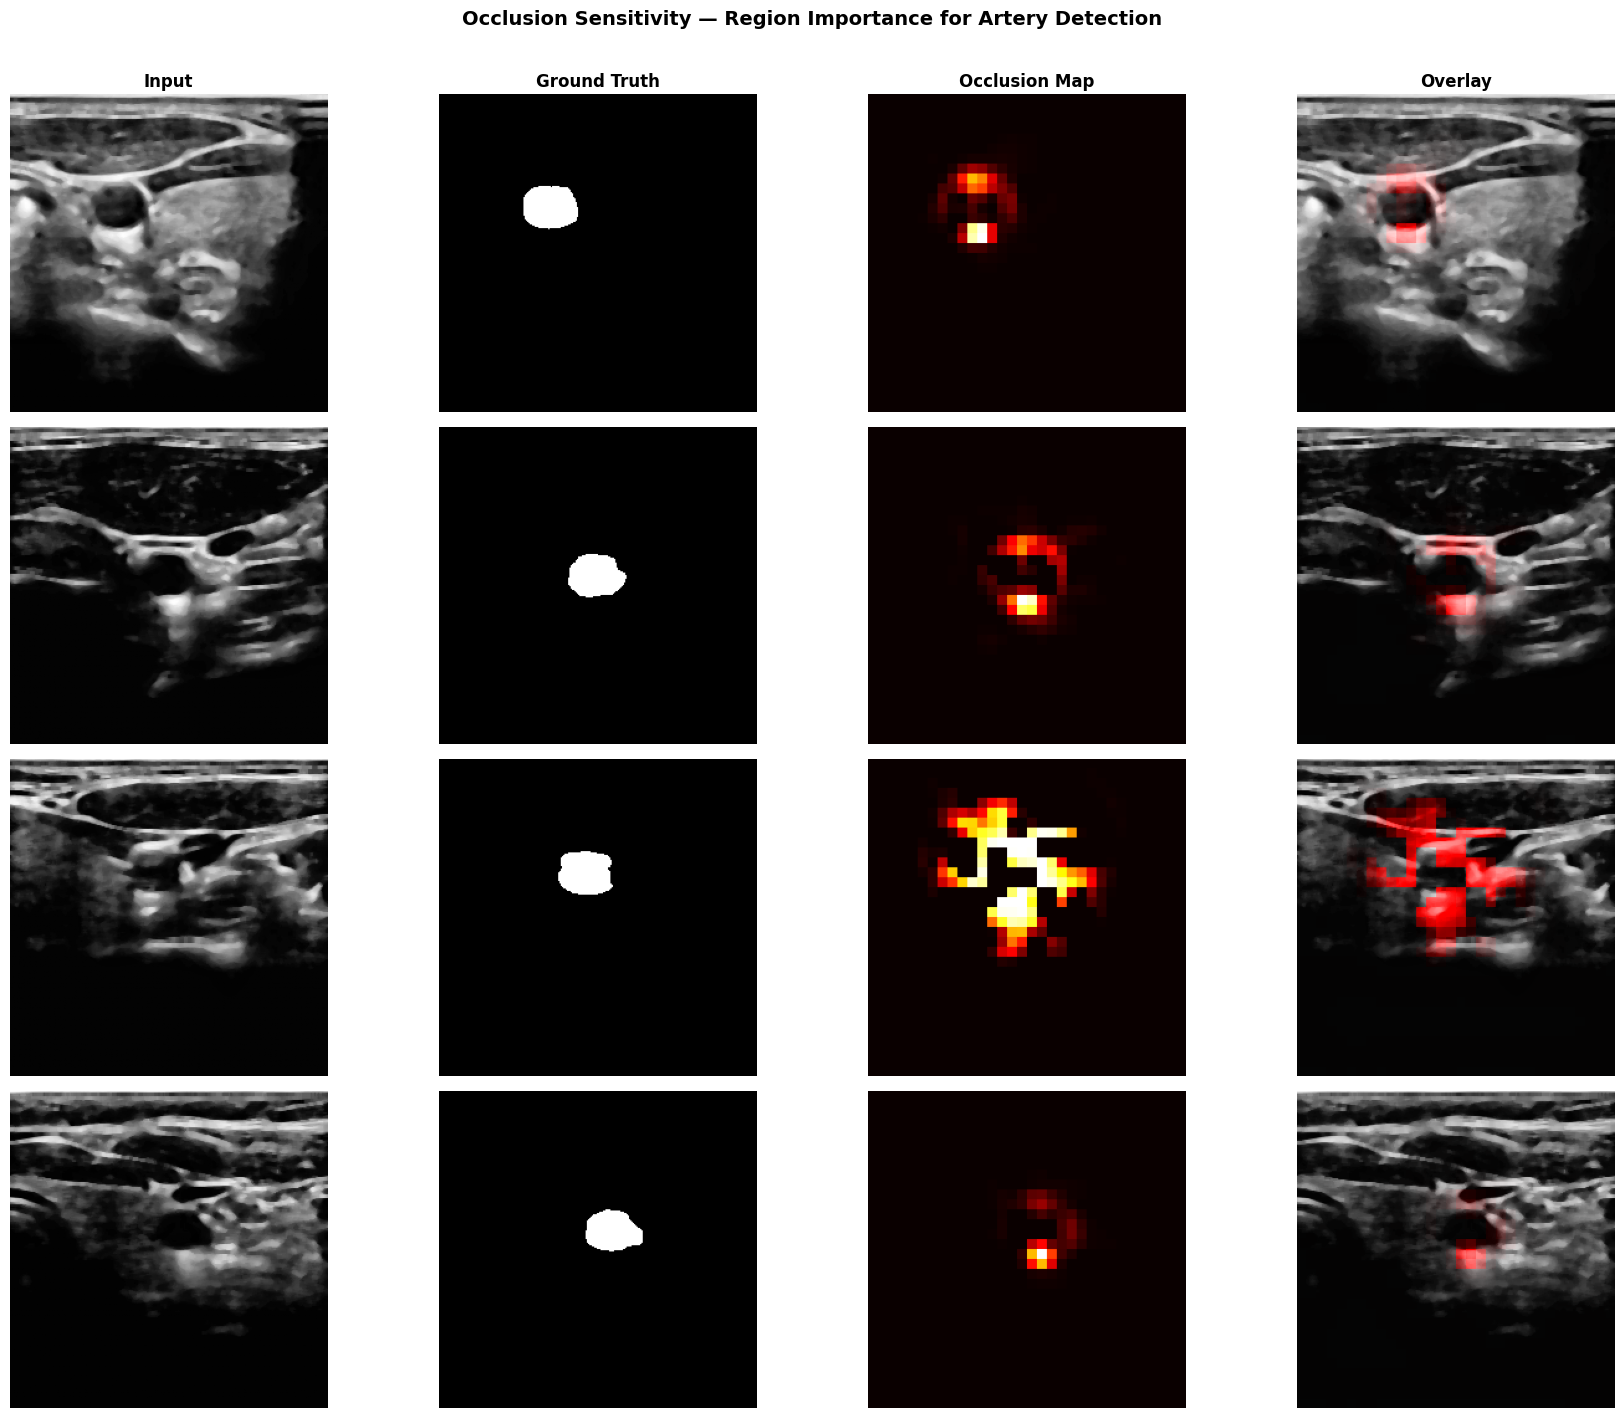

✅ Occlusion sensitivity saved.


In [38]:
# STEP 11 — Occlusion Sensitivity Map (no gradients, no hooks, pure numpy)
import gc
torch.cuda.empty_cache(); gc.collect()

model.eval()

def occlusion_sensitivity(model, img_tensor, patch_size=16, stride=8, device=DEVICE):
    """
    Slides a black patch across the image.
    Where prediction drops most = that region matters most.
    """
    img  = img_tensor.unsqueeze(0).to(device)
    H, W = img.shape[2], img.shape[3]

    with torch.no_grad():
        base_score = model(img).mean().item()

    heatmap = np.zeros((H, W), dtype=np.float32)
    counts  = np.zeros((H, W), dtype=np.float32)

    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):
            occluded = img.clone()
            occluded[:, :, y:y+patch_size, x:x+patch_size] = 0  # Black patch
            with torch.no_grad():
                score = model(occluded).mean().item()
            drop = base_score - score   # Higher drop = more important region
            heatmap[y:y+patch_size, x:x+patch_size] += drop
            counts[y:y+patch_size,  x:x+patch_size] += 1

    counts[counts == 0] = 1
    heatmap /= counts
    heatmap = np.clip(heatmap, 0, None)
    heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)
    return heatmap


n_samples = 4
indices   = random.sample(range(len(test_ds)), n_samples)

fig, axes = plt.subplots(n_samples, 4, figsize=(18, n_samples * 3.5))
for ax, t in zip(axes[0], ['Input', 'Ground Truth', 'Occlusion Map', 'Overlay']):
    ax.set_title(t, fontsize=12, fontweight='bold')

for row, idx in enumerate(indices):
    img, mask = test_ds[idx]
    print(f'⏳ Sample {row+1}/{n_samples}...')

    heatmap = occlusion_sensitivity(model, img)

    img_np  = img.squeeze().numpy()
    mask_np = mask.squeeze().numpy()
    img_rgb = np.stack([img_np]*3, axis=-1)
    overlay = img_rgb.copy()
    overlay[:,:,0] = np.clip(img_np + heatmap * 0.8, 0, 1)
    overlay[:,:,1] = np.clip(img_np - heatmap * 0.3, 0, 1)
    overlay[:,:,2] = np.clip(img_np - heatmap * 0.3, 0, 1)

    axes[row,0].imshow(img_np,   cmap='gray'); axes[row,0].axis('off')
    axes[row,1].imshow(mask_np,  cmap='gray'); axes[row,1].axis('off')
    axes[row,2].imshow(heatmap,  cmap='hot');  axes[row,2].axis('off')
    axes[row,3].imshow(overlay);               axes[row,3].axis('off')
    axes[row,0].set_ylabel(f'Sample {row+1}', fontsize=10)
    print(f'✅ Sample {row+1}/{n_samples} done')

plt.suptitle('Occlusion Sensitivity — Region Importance for Artery Detection',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/occlusion_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Occlusion sensitivity saved.')

In [40]:
print('=' * 60)
print('  EXPLAINABLE AI — CAROTID ARTERY BLOCKAGE DETECTION')
print('  PHASE 1 RESULTS SUMMARY')
print('=' * 60)
print(f'  Dataset         : Mendeley CCA — {len(full_dataset)} images')
print(f'  Train/Val/Test  : {n_train} / {n_val} / {n_test}')
print(f'  Model           : U-Net (PyTorch) — {total_params:,} params')
print(f'  Loss            : Combined Dice + BCE')
print(f'  Optimizer       : Adam (lr={LR})')
print(f'  Image Size      : {IMG_SIZE}x{IMG_SIZE}')
print()
print('  TEST METRICS:')
print(f'    Dice Score    : {test_dice:.4f}')
print(f'    IoU           : {test_iou:.4f}')
print(f'    F1 Score      : {test_f1:.4f}')
print(f'    Pixel Accuracy: {test_acc:.4f}')
print()
print('  OUTPUTS SAVED TO:', OUTPUT_DIR)
print('    slide1_collection.png')
print('    slide2_preprocessing.png')
print('    training_curves.png')
print('    test_metrics.png')
print('    predictions.png')
print('    gradcam.png')
print('    Occlusion_sensitivity.png')
print('    best_unet.pt')
print('=' * 60)

  EXPLAINABLE AI — CAROTID ARTERY BLOCKAGE DETECTION
  PHASE 1 RESULTS SUMMARY
  Dataset         : Mendeley CCA — 1100 images
  Train/Val/Test  : 770 / 165 / 165
  Model           : U-Net (PyTorch) — 31,036,481 params
  Loss            : Combined Dice + BCE
  Optimizer       : Adam (lr=0.0001)
  Image Size      : 256x256

  TEST METRICS:
    Dice Score    : 0.9618
    IoU           : 0.9266
    F1 Score      : 0.9619
    Pixel Accuracy: 0.9982

  OUTPUTS SAVED TO: /content/drive/MyDrive/major_project_full/output
    slide1_collection.png
    slide2_preprocessing.png
    training_curves.png
    test_metrics.png
    predictions.png
    gradcam.png
    Occlusion_sensitivity.png
    best_unet.pt
